✅ Loaded 2484 resumes
✅ Categories: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
✅ Experience levels: ['Entry', 'Mid', 'Senior']
✅ Train: 1987 | Test: 497

🧠 Training Category Classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.8s finished


✅ Category model saved!

🧠 Training Experience Classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


✅ Experience model saved!


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


✅ Model scores saved → results/metrics/model_scores.json
Category - Train: 0.9950, Test: 0.7565
Experience - Train: 0.9009, Test: 0.8994


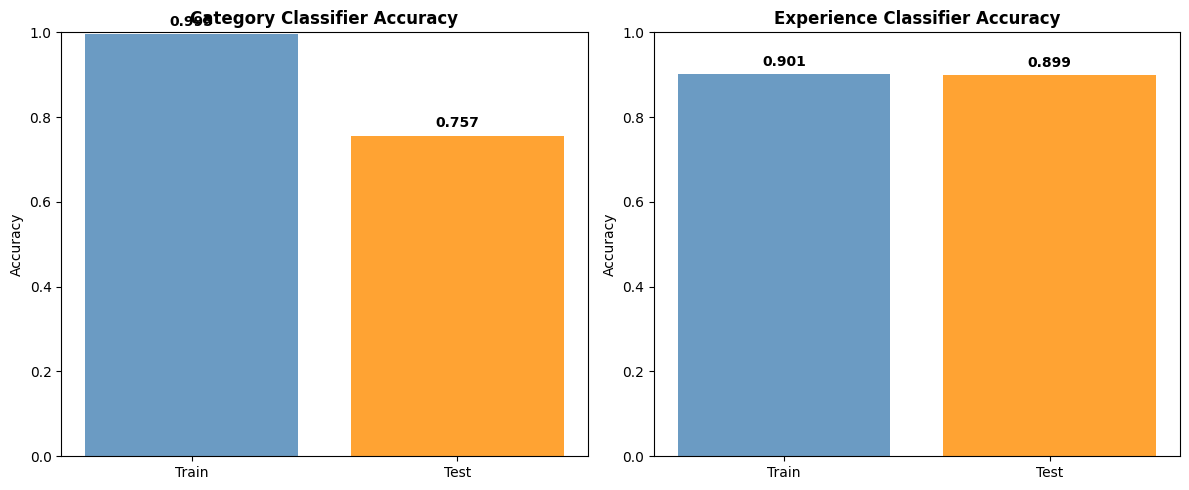

✅ Scores plot saved → results/plots/model_scores.png


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

📊 Category Report:
                         precision    recall  f1-score   support

            ACCOUNTANT       0.64      0.96      0.77        24
              ADVOCATE       0.80      0.83      0.82        24
           AGRICULTURE       1.00      0.38      0.56        13
               APPAREL       1.00      0.42      0.59        19
                  ARTS       0.60      0.14      0.23        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.79      0.92      0.85        24
               BANKING       0.82      0.61      0.70        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.81      0.92      0.86        24
                  CHEF       0.87      0.83      0.85        24
          CONSTRUCTION       0.90      0.86      0.88        22
            CONSULTANT       0.82      0.61      0.70        23
              DESIGNER       0.86      0.90      0.88        21
         DIGITAL-ME

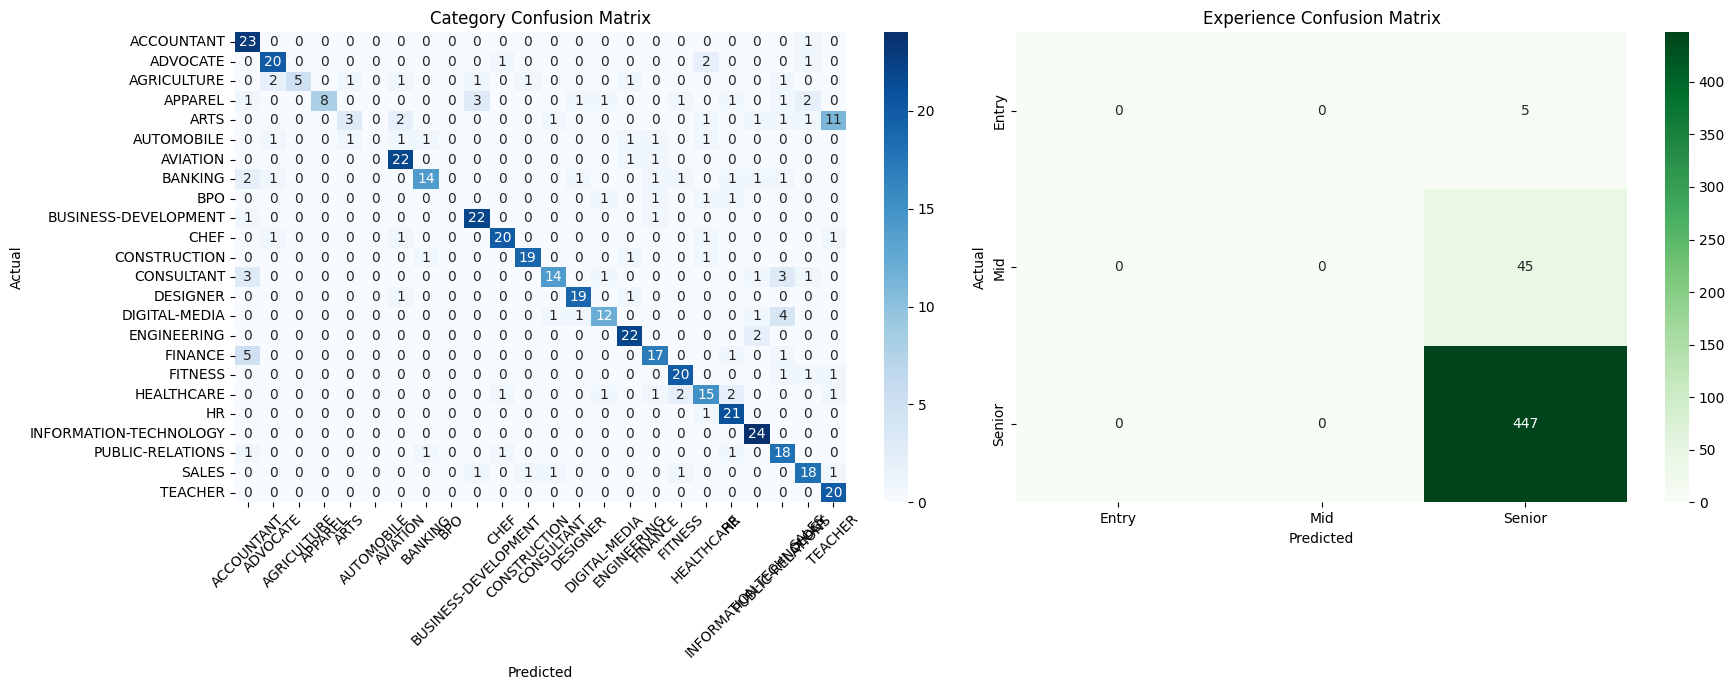

✅ Confusion matrices saved!


In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import pickle

os.makedirs("../results/models",  exist_ok=True)
os.makedirs("../results/plots",   exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)

# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
df = pd.read_csv("../data/resume_dataset.csv")
print(f"✅ Loaded {len(df)} resumes")

# ── Cell 3: Vectorize ─────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['clean_text'].fillna('')).toarray()

# ── Cell 4: Encode category labels ────────────────────────────────────────────
le_cat = LabelEncoder()
y_cat = le_cat.fit_transform(df['Category'])
num_cat_classes = len(le_cat.classes_)
print(f"✅ Categories: {list(le_cat.classes_)}")

# ── Cell 5: Encode experience labels ──────────────────────────────────────────
le_exp = LabelEncoder()
y_exp = le_exp.fit_transform(df['experience_level'])
num_exp_classes = len(le_exp.classes_)
print(f"✅ Experience levels: {list(le_exp.classes_)}")

# ── Cell 6: Train/test split ──────────────────────────────────────────────────
X_train, X_test, yc_train, yc_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y_cat)
_, _, ye_train, ye_test             = train_test_split(X, y_exp, test_size=0.2, random_state=42, stratify=y_exp)
print(f"✅ Train: {len(X_train)} | Test: {len(X_test)}")

# ── Cell 7: Build model function ──────────────────────────────────────────────
def build_model(num_classes):
    model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1, verbose=1)
    return model

# ── Cell 8: Train CATEGORY classifier ────────────────────────────────────────
print("\n🧠 Training Category Classifier...")
cat_model = build_model(num_cat_classes)
cat_model.fit(X_train, yc_train)
with open("../results/models/category_classifier_final.pkl", "wb") as f:
    pickle.dump(cat_model, f)
print("✅ Category model saved!")

# ── Cell 9: Train EXPERIENCE classifier ──────────────────────────────────────
print("\n🧠 Training Experience Classifier...")
exp_model = build_model(num_exp_classes)
exp_model.fit(X_train, ye_train)
with open("../results/models/exp_classifier_final.pkl", "wb") as f:
    pickle.dump(exp_model, f)
print("✅ Experience model saved!")

# ── Cell 10: Save training metrics and scores ──────────────────────────────────────────
cat_train_score = cat_model.score(X_train, yc_train)
cat_test_score = cat_model.score(X_test, yc_test)
exp_train_score = exp_model.score(X_train, ye_train)
exp_test_score = exp_model.score(X_test, ye_test)

scores = {
    'category_train': cat_train_score,
    'category_test': cat_test_score,
    'experience_train': exp_train_score,
    'experience_test': exp_test_score
}
with open("../results/metrics/model_scores.json", "w") as f:
    json.dump(scores, f, indent=2)
print("✅ Model scores saved → results/metrics/model_scores.json")
print(f"Category - Train: {cat_train_score:.4f}, Test: {cat_test_score:.4f}")
print(f"Experience - Train: {exp_train_score:.4f}, Test: {exp_test_score:.4f}")

# ── Cell 11: Plot training accuracy ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Train', 'Test']
cat_scores = [cat_train_score, cat_test_score]
axes[0].bar(models, cat_scores, color=['steelblue', 'darkorange'], alpha=0.8)
axes[0].set_title('Category Classifier Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
for i, v in enumerate(cat_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

exp_scores = [exp_train_score, exp_test_score]
axes[1].bar(models, exp_scores, color=['steelblue', 'darkorange'], alpha=0.8)
axes[1].set_title('Experience Classifier Accuracy', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
for i, v in enumerate(exp_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("../results/plots/model_scores.png", dpi=150)
plt.show()
print("✅ Scores plot saved → results/plots/model_scores.png")

# ── Cell 12: Evaluate & save reports ─────────────────────────────────────────
yc_pred = cat_model.predict(X_test)
ye_pred = exp_model.predict(X_test)

cat_report = classification_report(yc_test, yc_pred, target_names=le_cat.classes_)
exp_report = classification_report(ye_test, ye_pred, target_names=le_exp.classes_)

with open("../results/metrics/category_classification_report.txt", "w") as f:
    f.write(cat_report)
with open("../results/metrics/exp_classification_report.txt", "w") as f:
    f.write(exp_report)

print("📊 Category Report:\n", cat_report)
print("📊 Experience Report:\n", exp_report)

# ── Cell 13: Confusion matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(confusion_matrix(yc_test, yc_pred), annot=True, fmt='d',
            xticklabels=le_cat.classes_, yticklabels=le_cat.classes_,
            cmap='Blues', ax=axes[0])
axes[0].set_title('Category Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(ye_test, ye_pred), annot=True, fmt='d',
            xticklabels=le_exp.classes_, yticklabels=le_exp.classes_,
            cmap='Greens', ax=axes[1])
axes[1].set_title('Experience Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("../results/plots/combined_confusion_matrices.png", dpi=150)
plt.show()
print("✅ Confusion matrices saved!")